In [1]:
import qiskit
import pennylane as qml
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time

from pennylane import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,RobustScaler,PowerTransformer
from torch.optim import Adam
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.utils.validation import check_is_fitted

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

from scipy import stats

warnings.filterwarnings("ignore")

In [2]:
n_qubits = 4
dev = qml.device("default.qubit",wires=n_qubits)

In [3]:

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def get_angles(x):
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))

    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

@qml.qnode(dev)
def circuit(weights, x):

    wires=[wire for wire in range(n_qubits)]

    qml.StatePrep(x,wires=wires,normalize=True,pad_with=0.1)

    for layer_weights in weights:
        layer(layer_weights)
    

    return qml.expval(qml.PauliZ(0))

def variational_classifier(weights, bias, x,plot=False):
    
    if plot is True:
        fig, ax = qml.draw_mpl(circuit, expansion_strategy="device",style='pennylane')(weights, x)
        fig.suptitle('VQC circuit')
        fig.show()

    return circuit(weights, x) + bias

def layer(layer_weights):
    for wire in range(n_qubits):
        qml.Rot(*layer_weights[wire], wires=wire)
    
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            qml.CNOT(wires=[i, j])


def cost(weights, bias, X, Y):

    predictions = variational_classifier(weights, bias, X)
    return square_loss(Y, predictions)

def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


In [4]:

# method used to explore the class imbalance of our dataset
def class_imbalance(data_df: pd.DataFrame,field='diagnosis'):
    df=data_df
    # order=['B','M'] # the order that we want to present our classes

    # # we find how many entries per class
    entries=df[field].value_counts()
    print(f'Absolute frequencies of field "{field}"')
    print(entries)

    # the same as above, but in percentage
    fractions=df[field].value_counts(normalize=True)
    print(f'Percentage of each class of field "{field}"')
    print(fractions)


In [5]:
imp=IterativeImputer(random_state=42)
enc=LabelEncoder()
scaler=RobustScaler()
pca=PCA(n_components=np.power(2,n_qubits))
minmaxscaler=MinMaxScaler()

In [6]:
df_train=pd.read_csv('./cancer_data/clean_train_subset.csv')
class_imbalance(data_df=df_train)

y_train=df_train['diagnosis'].values
y_train = np.array(y_train, requires_grad=False)

id=df_train['id']
x_train=df_train.drop(columns=['diagnosis','id'])
x_train.head()

Absolute frequencies of field "diagnosis"
diagnosis
-1    214
 1    127
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.627566
 1    0.372434
Name: proportion, dtype: float64


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,14.780,23.94,97.40,668.3,0.11720,0.14790,0.12670,0.09029,0.1953,0.06654,...,17.31,33.39,114.60,925.1,0.16480,0.34160,0.3024,0.16140,0.3321,0.08911
1,9.667,18.49,61.49,289.1,0.08946,0.06258,0.02948,0.01514,0.2238,0.06413,...,11.14,25.62,70.88,385.2,0.12340,0.15420,0.1277,0.06560,0.3174,0.08524
2,14.640,16.85,94.21,666.0,0.08641,0.06698,0.05192,0.02791,0.1409,0.05355,...,16.46,25.44,106.00,831.0,0.11420,0.20700,0.2437,0.07828,0.2455,0.06596
3,19.550,23.21,128.90,1174.0,0.10100,0.13180,0.18560,0.10210,0.1989,0.05884,...,20.82,30.44,142.00,1313.0,0.12510,0.24140,0.3829,0.18250,0.2576,0.07602
4,12.270,29.97,77.42,465.4,0.07699,0.03398,0.00000,0.00000,0.1701,0.05960,...,13.45,38.05,85.08,558.9,0.09422,0.05213,0.0000,0.00000,0.2409,0.06743


In [7]:
x_scaled_train=scaler.fit_transform(x_train)

X_pca = pca.fit_transform(x_scaled_train)

print(pca.explained_variance_ratio_)
print(np.sum(pca.explained_variance_ratio_))

[0.42340938 0.20634479 0.10801561 0.0601497  0.04652353 0.04201217
 0.02462915 0.01608987 0.01386469 0.01277824 0.01118022 0.00925264
 0.00726867 0.00392152 0.00288655 0.00251218]
0.9908389011659942


In [8]:
# Put back into a DataFrame if you want
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2','PC3','PC4','PC5', 'PC6','PC7','PC8','PC9', 'PC10','PC11','PC12','PC13', 'PC14','PC15','PC16'])
df_pca['diagnosis'] = y_train
df_pca['id']=id.reset_index(drop=True)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,diagnosis,id
0,0.887967,0.346808,-1.671672,-0.931214,0.609436,-0.871115,0.585322,0.379957,0.131463,0.076147,0.087768,-0.485472,0.486861,0.299624,-0.099173,0.099421,1,859283
1,-1.956087,1.197388,0.730349,-1.000491,0.013521,0.178424,-0.511392,0.460595,-0.560268,0.671655,1.045611,0.569947,-0.146401,-0.140843,-0.092095,-0.026485,-1,9113778
2,-2.453626,-1.762212,-0.731205,1.264188,-0.022688,0.391145,-0.065240,0.257351,0.250558,-0.422570,-0.504736,0.219451,-0.005375,0.407473,-0.026739,-0.097629,-1,913102
3,4.828368,0.365623,2.229915,1.209419,1.556472,-0.033765,2.384056,0.472501,1.141615,0.339008,0.435733,-0.339014,-1.043175,-0.568477,-0.313631,0.429024,1,90312
4,-2.591409,-1.244160,2.908561,-1.901938,3.825650,-0.398806,-0.781759,0.106997,1.070446,0.587132,-1.041717,0.281784,0.030796,-0.148629,-0.012012,-0.135732,-1,9113846


In [9]:
df_pca.to_csv('./pca_datasets/pca16_clean_train_subset.csv',index=False)

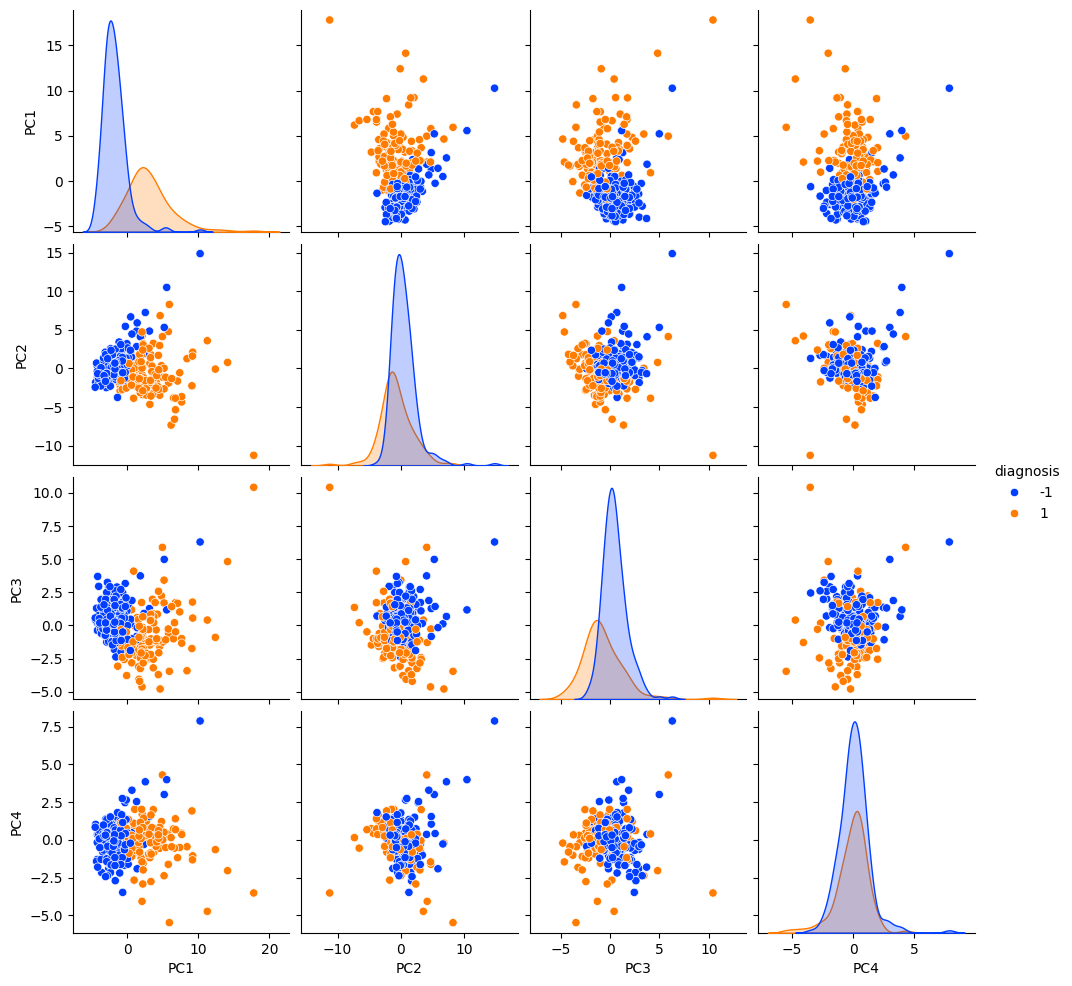

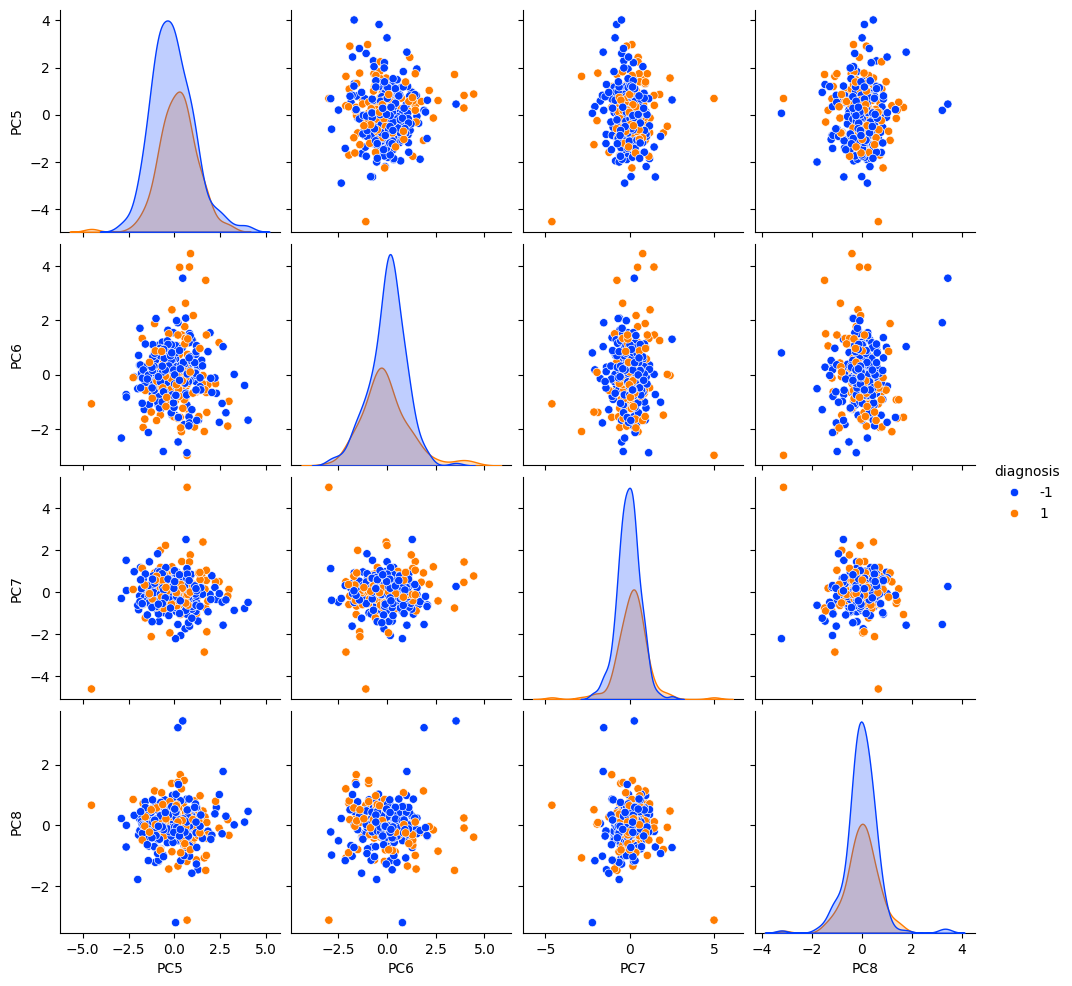

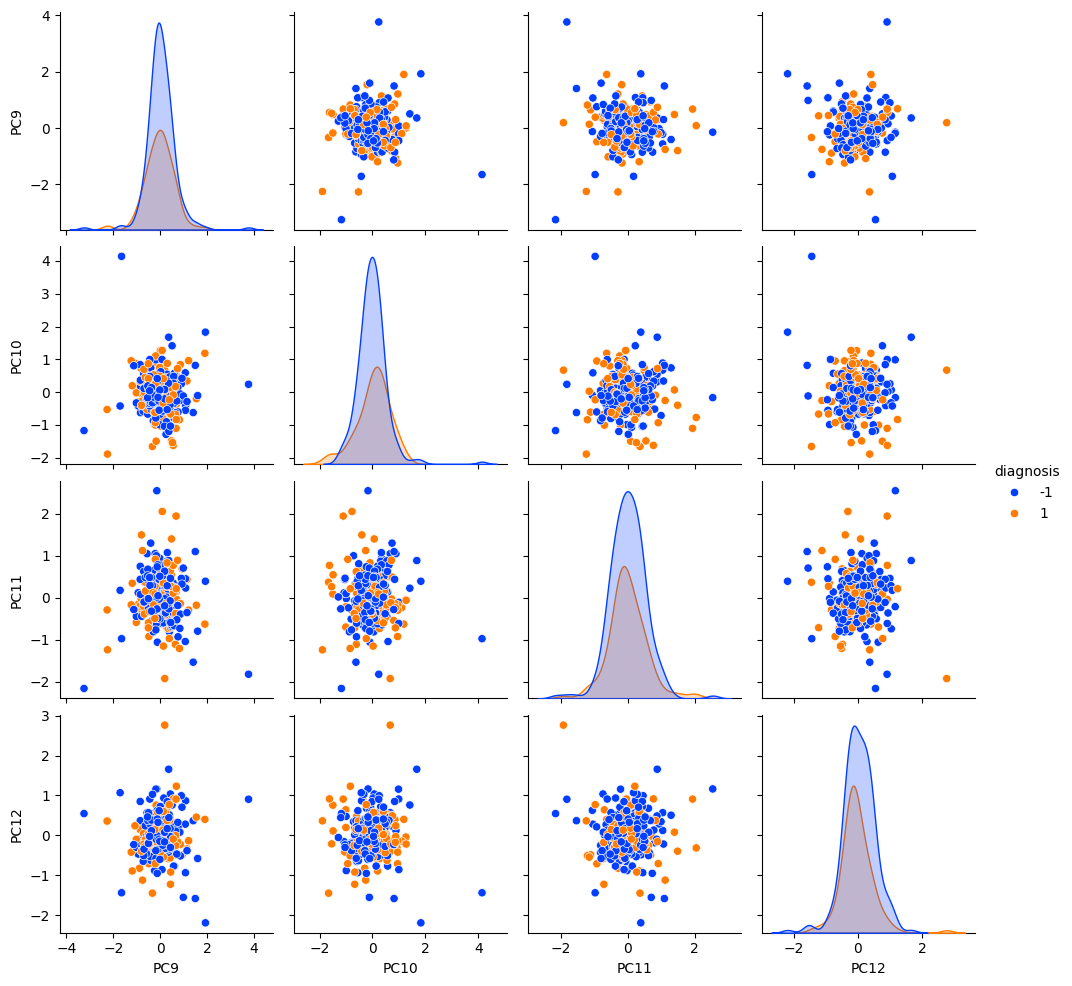

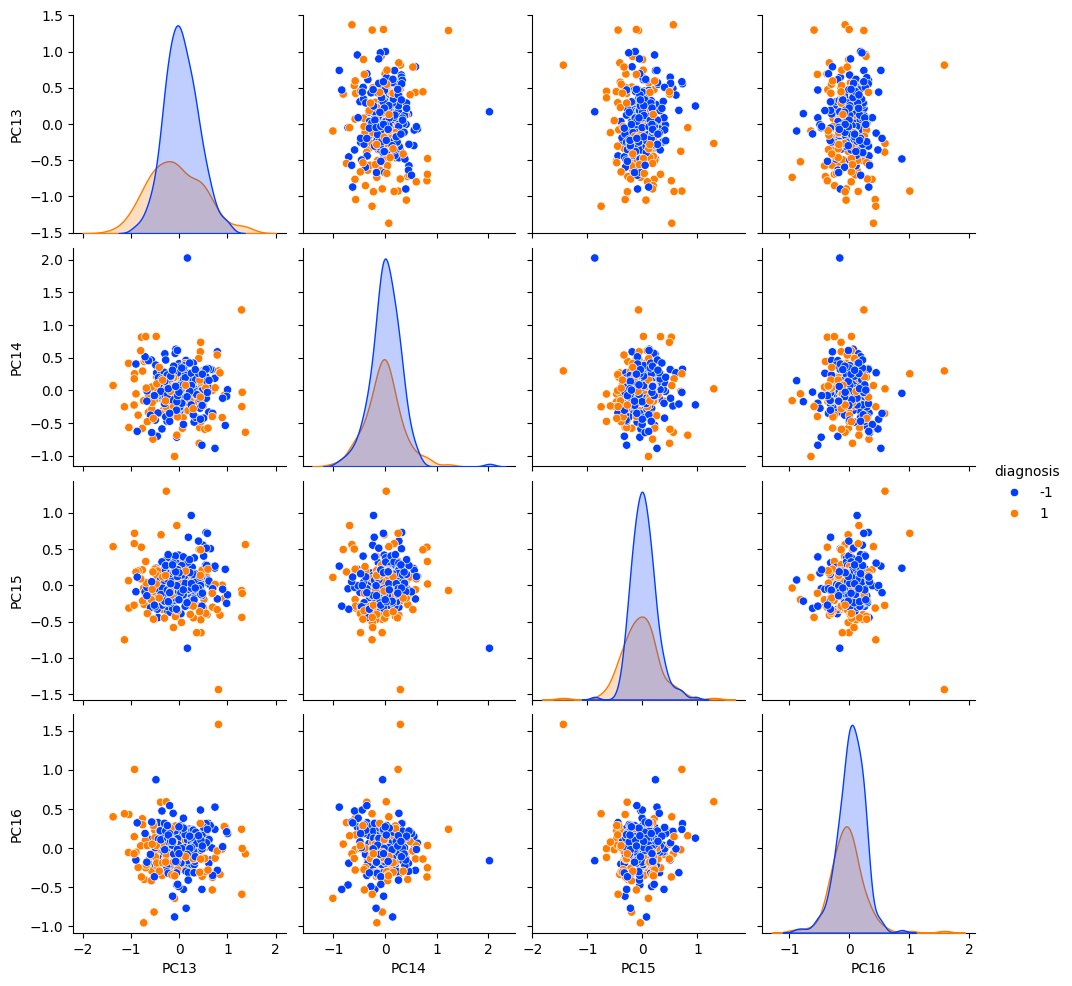

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of 30 feature names (excluding 'id' and 'diagnosis')
feats = [col for col in df_pca.columns if col not in ['id', 'diagnosis']]

# Define the number of features per plot
n = 4 

# Loop through the features in chunks of n
for i in range(0, len(feats), n):
    subset = feats[i:i+n]
    
    # Create the pairplot for this subset, coloring by Diagnosis
    sns.pairplot(df_pca, vars=subset, hue='diagnosis',palette='bright')
    plt.show()

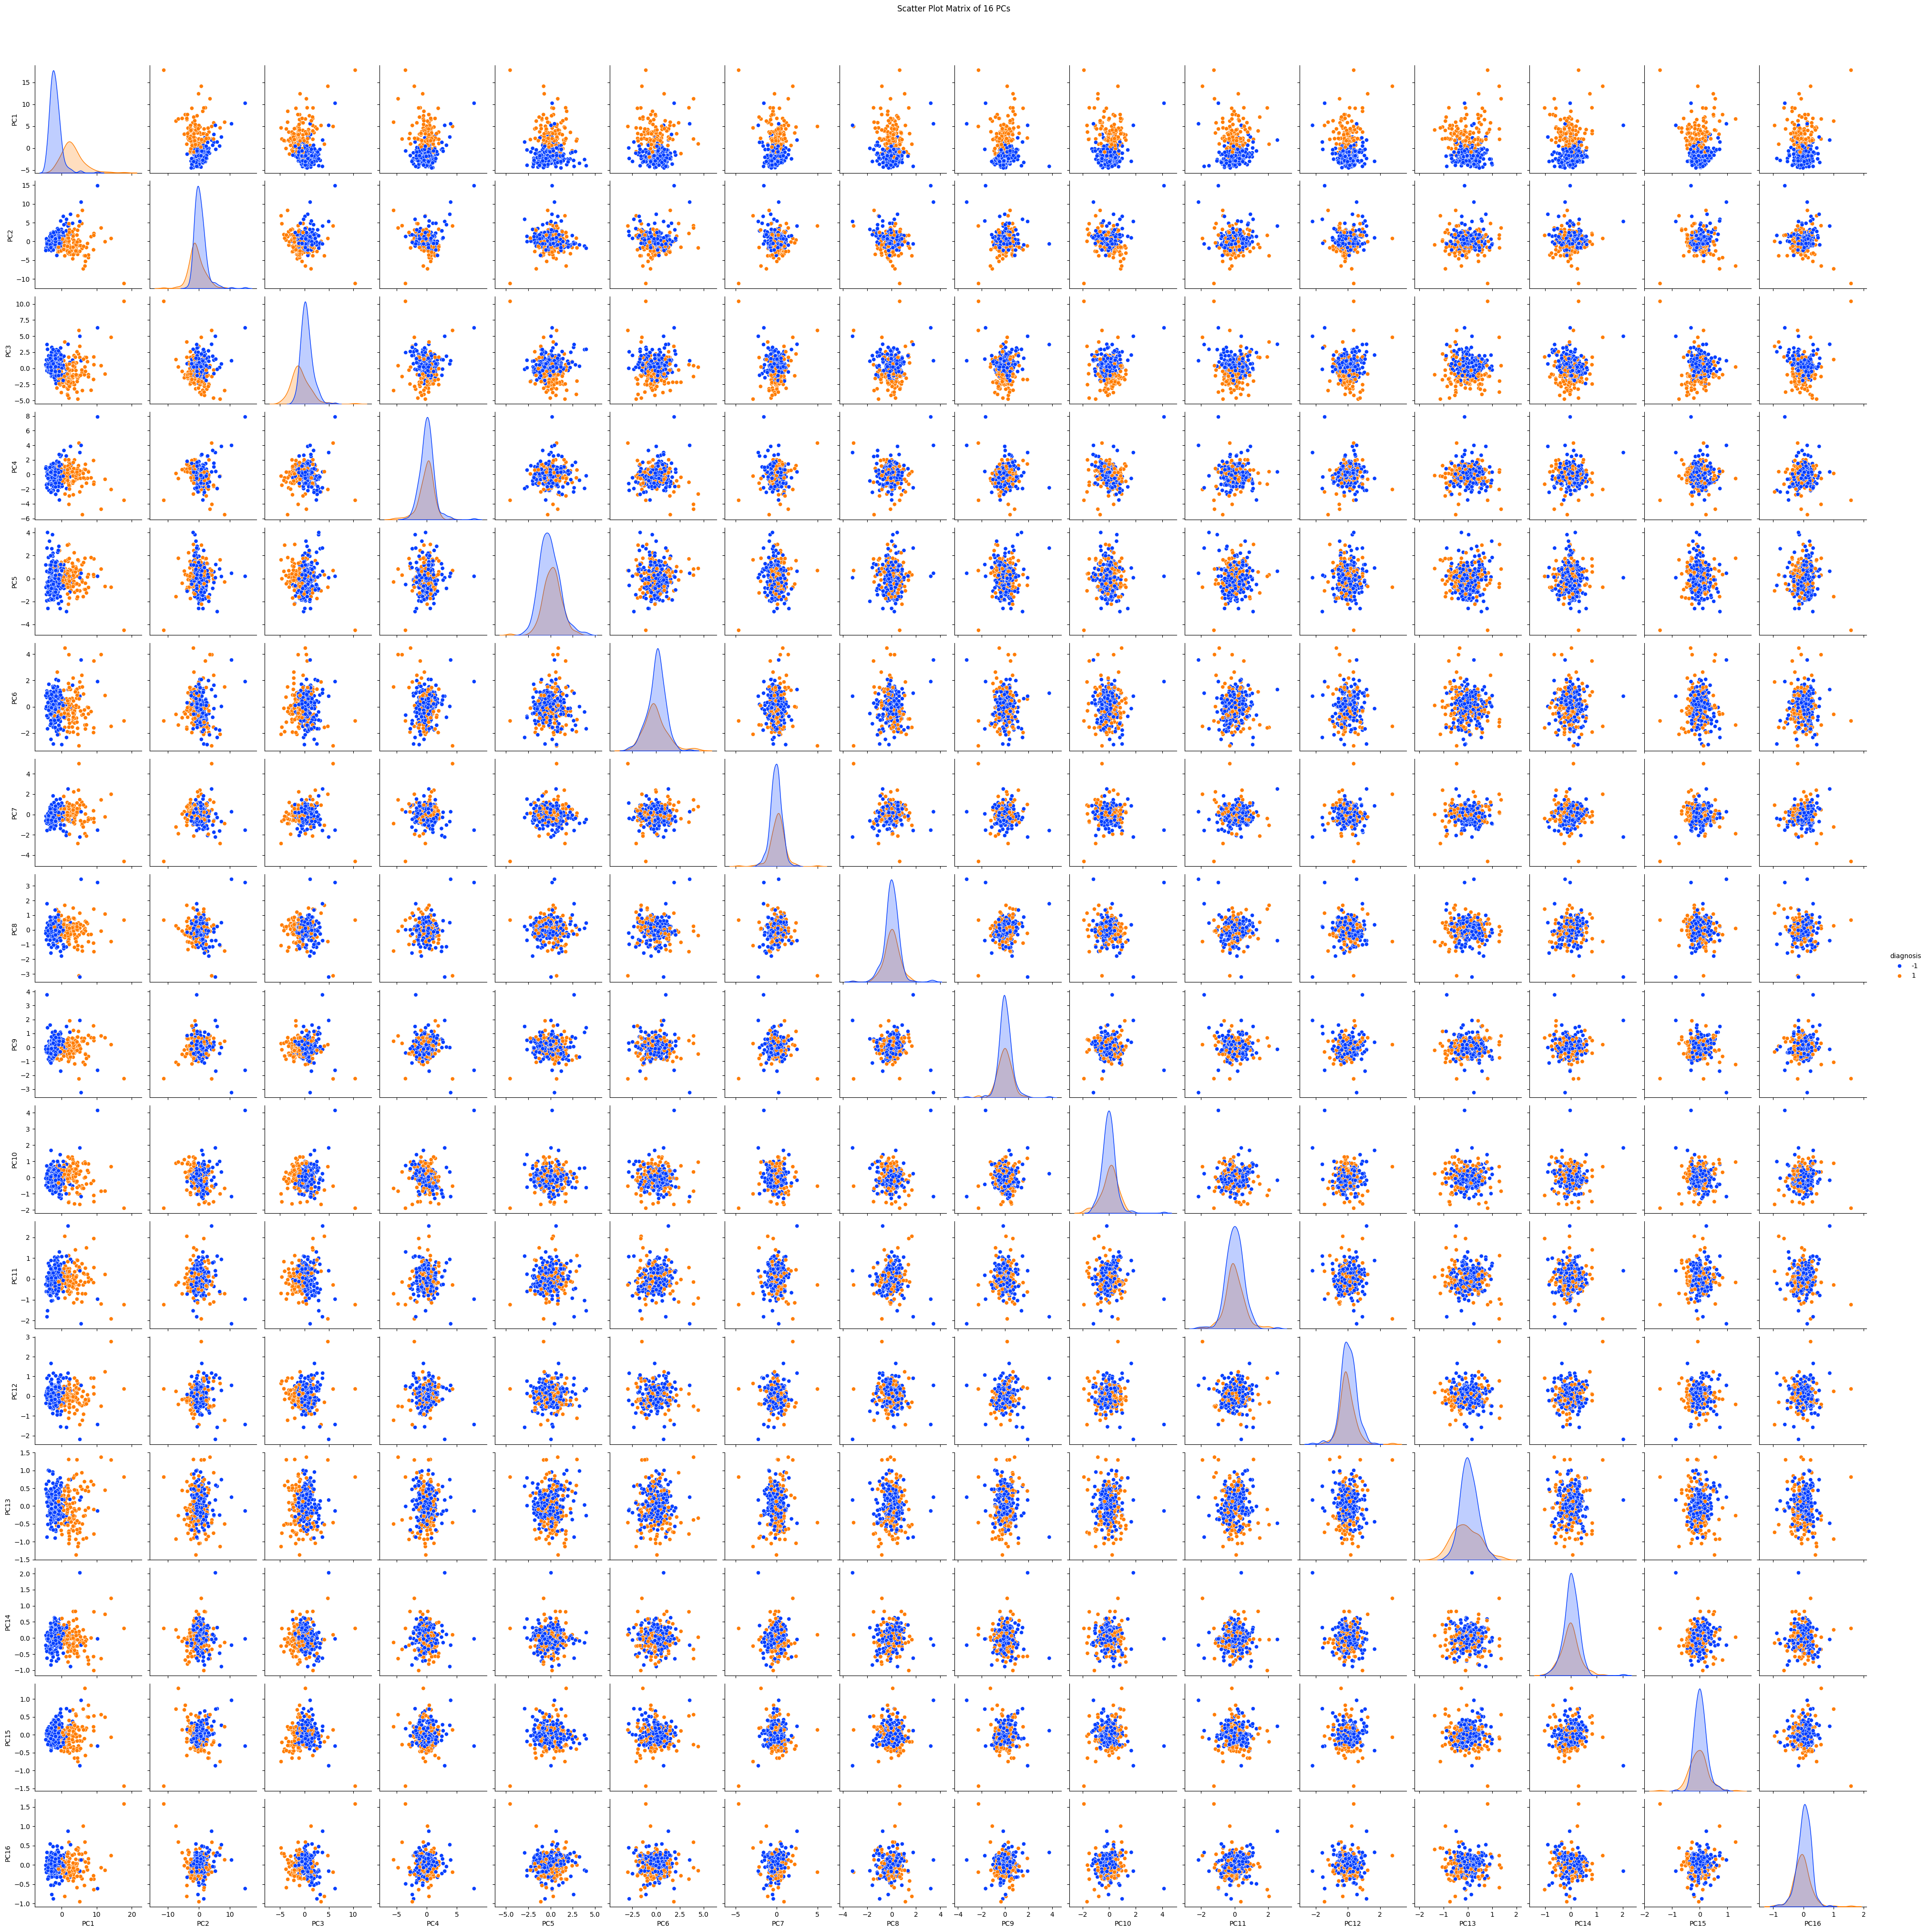

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df_pca, vars=['PC1', 'PC2','PC3','PC4','PC5', 'PC6','PC7','PC8','PC9', 'PC10','PC11','PC12','PC13', 'PC14','PC15','PC16'], hue="diagnosis",palette='bright')
plt.suptitle(f"Scatter Plot Matrix of {np.power(2,n_qubits)} PCs", y=1.02) # y adjusts title height
plt.show()

In [11]:
y_pca_train=df_pca['diagnosis']
x_pca_train=df_pca.drop(columns=['diagnosis','id'])
x_pca_train=np.array(x_pca_train,requires_grad=False)
x_pca_train=minmaxscaler.fit_transform(x_pca_train)

In [12]:
print(f"First X sample (original)  : {x_pca_train[0]}")

First X sample (original)  : [0.24145086 0.44410894 0.20501611 0.34114229 0.60109969 0.28284598
 0.54155695 0.53948464 0.48187029 0.32619817 0.47770926 0.34412348
 0.67765286 0.43176093 0.48927511 0.41578191]


In [13]:
features = np.array(x_pca_train, requires_grad=False)
y_train = np.array(y_train, requires_grad=False)

In [14]:
df_val=pd.read_csv('./cancer_data/clean_val_subset.csv')

df_val.head()

class_imbalance(data_df=df_val)

y_val=df_val['diagnosis'].values

Absolute frequencies of field "diagnosis"
diagnosis
-1    71
 1    43
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.622807
 1    0.377193
Name: proportion, dtype: float64


In [15]:
id_val=df_val['id']
x_val=df_val.drop(columns=['diagnosis','id'])
x_val.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.160,18.03,78.29,455.3,0.09087,0.07838,0.02916,0.015270,0.1464,0.06284,...,13.34,27.87,88.83,547.4,0.1208,0.22790,0.16200,0.05690,0.2406,0.07729
1,12.720,13.78,81.78,492.1,0.09667,0.08393,0.01288,0.019240,0.1638,0.06100,...,13.50,17.48,88.54,553.7,0.1298,0.14720,0.05233,0.06343,0.2369,0.06922
2,9.683,19.34,61.05,285.7,0.08491,0.05030,0.02337,0.009615,0.1580,0.06235,...,10.93,25.59,69.10,364.2,0.1199,0.09546,0.09350,0.03846,0.2552,0.07920
3,11.670,20.02,75.21,416.2,0.10160,0.09453,0.04200,0.021570,0.1859,0.06461,...,13.35,28.81,87.00,550.6,0.1550,0.29640,0.27580,0.08120,0.3206,0.08950
4,12.700,12.17,80.88,495.0,0.08785,0.05794,0.02360,0.024020,0.1583,0.06275,...,13.65,16.92,88.12,566.9,0.1314,0.16070,0.09385,0.08224,0.2775,0.09464


In [16]:
x_scaled_val=scaler.transform(x_val)

X_pca_val = pca.transform(x_scaled_val)

print(pca.explained_variance_ratio_)
print(np.sum(pca.explained_variance_ratio_))

[0.42340938 0.20634479 0.10801561 0.0601497  0.04652353 0.04201217
 0.02462915 0.01608987 0.01386469 0.01277824 0.01118022 0.00925264
 0.00726867 0.00392152 0.00288655 0.00251218]
0.9908389011659942


In [17]:
# Put back into a DataFrame if you want
df_pca_val = pd.DataFrame(X_pca_val, columns=['PC1', 'PC2','PC3','PC4','PC5', 'PC6','PC7','PC8','PC9', 'PC10','PC11','PC12','PC13', 'PC14','PC15','PC16'])
df_pca_val['diagnosis'] = y_val
df_pca_val['id']=id_val.reset_index(drop=True)

df_pca_val.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,diagnosis,id
0,-2.873173,-0.531658,-0.302094,0.383071,0.124775,-0.418088,-0.606888,0.189174,0.278018,-0.628399,-0.311470,0.057777,0.162301,0.186829,0.293177,0.001897,-1,912193
1,-3.226225,-0.712070,-0.275600,0.315395,-1.487517,-0.170318,0.392706,0.129819,0.261197,-0.248504,0.152433,0.087143,0.198114,0.156474,0.298266,0.087576,-1,891716
2,-2.938186,0.602597,1.362444,-0.101133,0.180971,-0.174026,-0.445655,0.105769,-0.354437,-0.109855,-0.099270,-0.455698,-0.161915,-0.230141,-0.247809,-0.082805,-1,923169
3,-2.071601,0.580130,-1.551945,-0.577798,0.018177,-0.482019,-0.531814,0.307270,-0.538663,0.001516,0.061060,0.090743,0.219142,0.473109,0.113806,0.029538,-1,91903901
4,-2.633458,0.163309,-0.271350,0.300445,-1.661876,0.000100,-0.507298,-0.659738,0.079829,0.332564,-0.276632,-0.309357,-0.567447,-0.238442,-0.259659,0.042882,-1,906024


In [18]:
df_pca_val.to_csv('./pca_datasets/pca16_clean_val_subset.csv',index=False)

In [19]:
y_pca_val=df_pca_val['diagnosis']
x_pca_val=df_pca_val.drop(columns=['diagnosis','id'])
x_pca_val=np.array(x_pca_val,requires_grad=False)
x_pca_val=minmaxscaler.transform(x_pca_val)

In [20]:
print(f"First X VAL sample (original)  : {x_pca_val[0]}")

First X VAL sample (original)  : [0.07279527 0.41045057 0.29506046 0.43951218 0.54434259 0.34388914
 0.41751019 0.51079411 0.50274999 0.20936386 0.39276625 0.45379657
 0.5592082  0.39459094 0.63274964 0.37731796]


In [21]:
features_val = np.array(x_pca_val, requires_grad=False)
y_val = np.array(y_val, requires_grad=False)

In [22]:
df_test=pd.read_csv('./cancer_data/clean_test_subset.csv')

df_test.head()
class_imbalance(data_df=df_test)

Absolute frequencies of field "diagnosis"
diagnosis
-1    72
 1    42
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.631579
 1    0.368421
Name: proportion, dtype: float64


In [23]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,...,13.67,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924
1,14.50,10.89,94.28,640.7,0.11010,0.10990,0.08842,0.05778,0.1856,0.06402,...,15.70,15.98,102.80,745.5,0.1313,0.1788,0.2560,0.12210,0.2889,0.08006
2,12.36,18.54,79.01,466.7,0.08477,0.06815,0.02643,0.01921,0.1602,0.06066,...,13.29,27.49,85.56,544.1,0.1184,0.1963,0.1937,0.08442,0.2983,0.07185
3,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,0.06217,...,12.37,17.70,79.12,467.2,0.1121,0.1610,0.1648,0.06296,0.1811,0.07427
4,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,14.50,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183


In [24]:
x_scaled_test=scaler.transform(x_clean_test)

X_pca_test = pca.transform(x_scaled_test)

print(pca.explained_variance_ratio_)
print(np.sum(pca.explained_variance_ratio_))

[0.42340938 0.20634479 0.10801561 0.0601497  0.04652353 0.04201217
 0.02462915 0.01608987 0.01386469 0.01277824 0.01118022 0.00925264
 0.00726867 0.00392152 0.00288655 0.00251218]
0.9908389011659942


In [25]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,...,13.67,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924
1,14.50,10.89,94.28,640.7,0.11010,0.10990,0.08842,0.05778,0.1856,0.06402,...,15.70,15.98,102.80,745.5,0.1313,0.1788,0.2560,0.12210,0.2889,0.08006
2,12.36,18.54,79.01,466.7,0.08477,0.06815,0.02643,0.01921,0.1602,0.06066,...,13.29,27.49,85.56,544.1,0.1184,0.1963,0.1937,0.08442,0.2983,0.07185
3,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,0.06217,...,12.37,17.70,79.12,467.2,0.1121,0.1610,0.1648,0.06296,0.1811,0.07427
4,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,14.50,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183


In [26]:
df_pca_test = pd.DataFrame(X_pca_test, columns=['PC1', 'PC2','PC3','PC4','PC5', 'PC6','PC7','PC8','PC9', 'PC10','PC11','PC12','PC13', 'PC14','PC15','PC16'])
df_pca_test['diagnosis'] = y_test
df_pca_test['id']=id_test.reset_index(drop=True)

df_pca_test.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,diagnosis,id
0,-2.122452,0.472744,-0.593337,-0.851118,-0.230931,0.568554,0.087893,0.440851,-0.208651,0.588591,0.100338,0.641870,-0.245233,0.463445,-0.018848,0.086551,-1,8612080
1,-0.981370,-0.015934,-0.866595,0.227543,-1.884438,0.714560,0.280929,0.911438,0.823609,0.346733,-0.199889,-0.227881,0.058504,-0.033424,-0.030475,0.080853,-1,865432
2,-3.328849,-0.674335,-1.167721,0.377311,0.194839,0.371516,-0.403390,0.357893,-0.156558,-0.170003,0.012330,0.070128,0.108756,0.116494,0.025081,0.170529,-1,863270
3,-1.624118,1.147497,1.888421,2.183122,-0.903588,0.073442,0.064680,0.036118,0.343409,-1.288048,-0.481494,-0.657182,-0.158059,0.236558,0.187474,0.081816,-1,873843
4,-1.883230,0.406613,-1.483069,-0.486652,-1.048303,0.356484,-0.299183,0.291187,0.465182,0.241531,0.198417,0.183654,0.625426,0.270801,0.539758,0.115726,-1,8510653


In [27]:
df_pca_test.to_csv('./pca_datasets/pca16_clean_test_subset.csv',index=False)

In [28]:
y_pca_test=df_pca_test['diagnosis']
x_pca_test=df_pca_test.drop(columns=['diagnosis','id'])
x_pca_test=np.array(x_pca_test)
x_pca_test=minmaxscaler.transform(x_pca_test)

In [29]:
features_test = np.array(x_pca_test, requires_grad=False)
y_test = np.array(y_test, requires_grad=False)

In [30]:
layers=[1,5,10,15]
num_epochs = 300
runs=10

num_qubits = n_qubits

In [31]:

metrics_dict={}

for num_layer in layers:

    metrics_dict[num_layer]={}
    metrics_dict[num_layer]['Accuracy']=[]
    metrics_dict[num_layer]['Precision']=[]
    metrics_dict[num_layer]['Recall']=[]
    metrics_dict[num_layer]['F1']=[]
    metrics_dict[num_layer]['Best Epoch']=[]
    metrics_dict[num_layer]['Training Time']=[] 

metrics_dict

{1: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []},
 5: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []},
 10: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []},
 15: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []}}

---> Repetition 1/10 for VQC with 4 Qubits and 1 Layers <---



---> Repetition 2/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 3/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 4/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 5/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 6/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 7/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 8/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 9/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 10/10 for VQC with 4 Qubits and 1 Layers <---


 Average Test set performance of Unbiased VQC for 4 Qubits and 1 Layers:
Accuracy : 0.6140
Precision: 0.5035
Recall   : 0.5010
F1-score : 0.4364
---> Repetition 1/10 for VQC with 4 Qubits and 5 Layers <---

---> Repetition 2/10 for VQC with 4 Qubits and 5 Layers <---

---> Repetition 3/10 for VQC with 4 Qubits and 5 Layers <---

---> Repetition 4/10 for VQC with 4 Qubits and 5 Layers <---

---> Repetition 5/10 for VQC with 4 Qubits and 

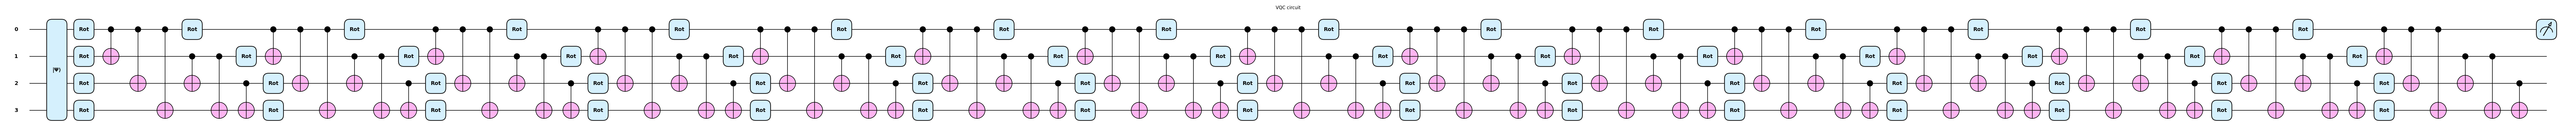

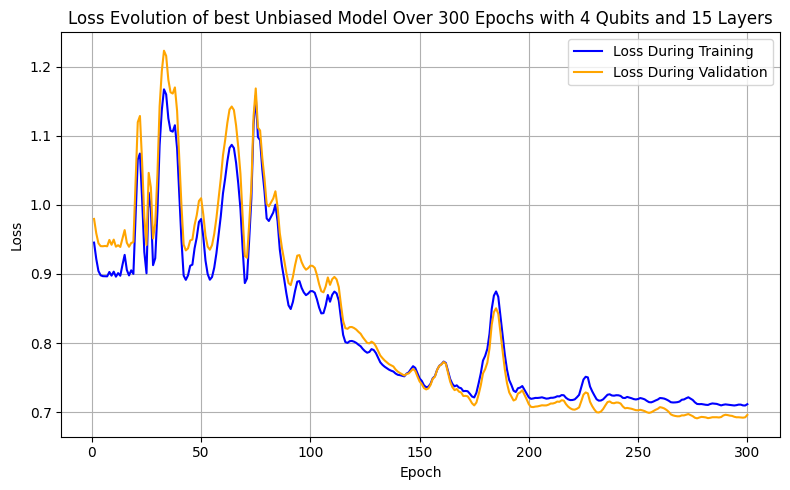

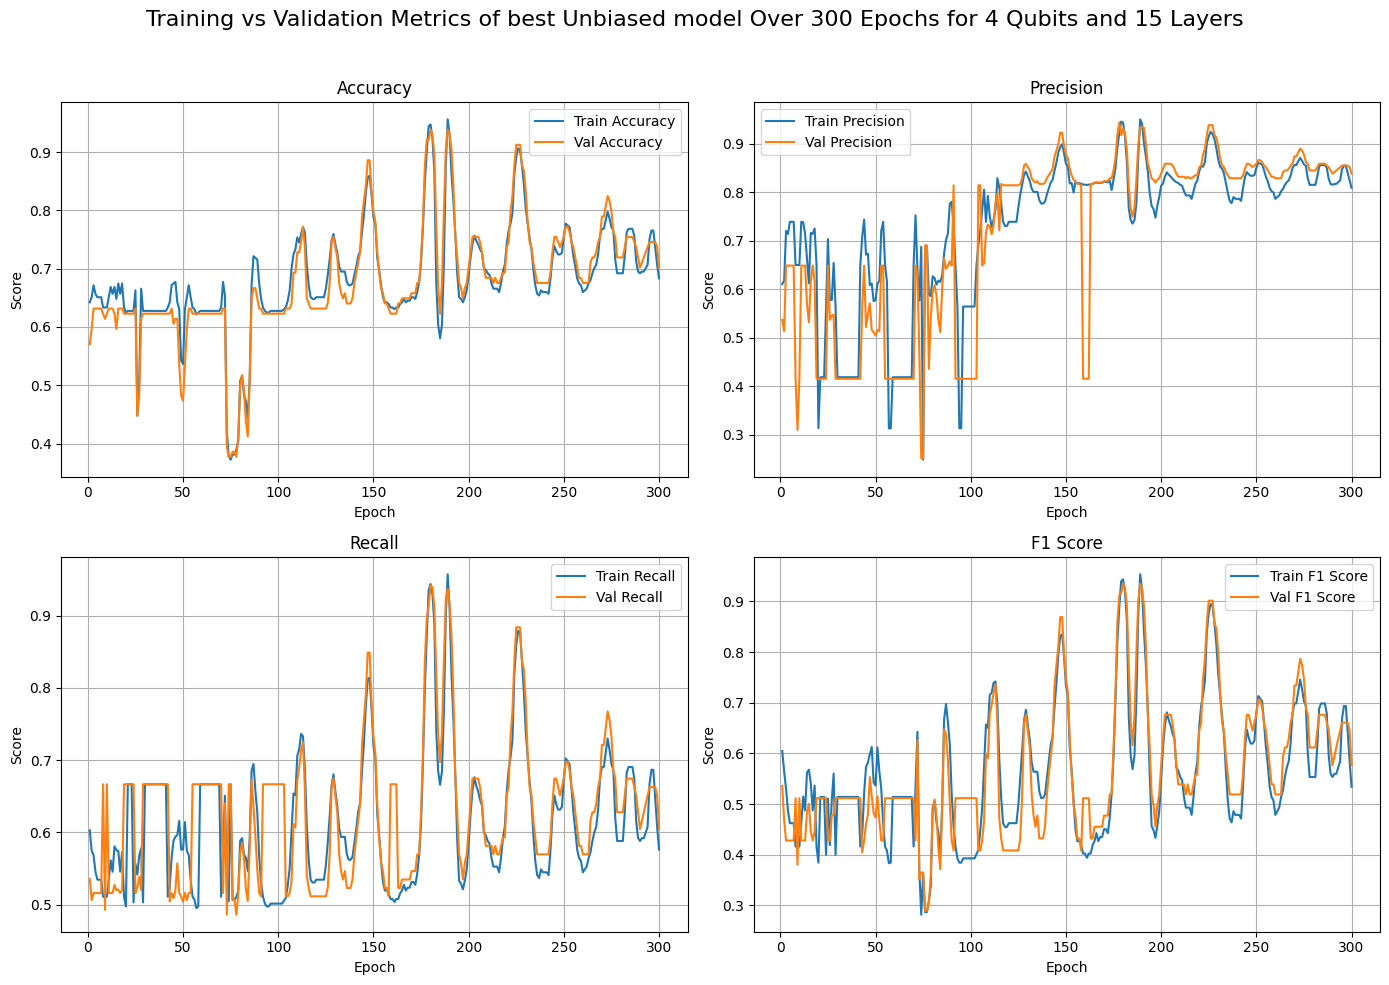

In [ ]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))


best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0

best_losses=[]
best_val_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

test_acc=[]
test_prec=[]
test_rec=[]
test_f1=[]

best_epoch=0
biased=False

for num_layers in layers:


    layer_acc=[] # For Test set
    layer_prec=[] # For Test set
    layer_rec=[] # For Test set
    layer_f1=[] # For Test set
    layer_epoch=[] # For Test set
    layer_time=[] # For Training time

    for rep in range(runs):
        print(f"---> Repetition {rep+1}/{runs} for VQC with {num_qubits} Qubits and {num_layers} Layers <---\n")

        weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
        bias_init = np.array(0.0,requires_grad=biased)


        opt = NesterovMomentumOptimizer(0.01)
        batch_size = 5

        # Tracking loss
        losses = []
        val_losses=[]

        # Tracking Train accuracy
        tr_acc=[]

        # Tracking Validation accuracy
        val_acc=[]

        # Tracking Train precision
        tr_prec=[]

        # Tracking Validation precision
        val_prec=[]

        # Tracking Train recall
        tr_recall=[]

        # Tracking Validation recall
        val_recall=[]

        # Tracking Train F1
        tr_f1=[]

        # Tracking Validation F1
        val_f1=[]

        # Initialize weights
        weights = weights_init
        bias = bias_init
        
        val_best_acc=0.0
        val_best_weights=None
        val_best_bias=0.0

        val_best_epoch=0

        start=time.perf_counter()
        # We Train inside this loop
        for it in range(num_epochs):
            # Mini-batch sampling
            batch_index = np.random.randint(0, num_data, (batch_size,))
            feats_train_batch = features[batch_index]
            Y_train_batch = y_train[batch_index]

            # Optimizer step
            weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

            plot=False
            # Predictions
            pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
            pred_val = np.sign(variational_classifier(weights, bias, features_val))

            # Metrics
            acc_train = accuracy_score(y_train, pred_train)
            acc_val = accuracy_score(y_val, pred_val)
            prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
            prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
            rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
            rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
            f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
            f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

            tr_acc.append(acc_train)
            val_acc.append(acc_val)
            tr_prec.append(prec_train)
            val_prec.append(prec_val)
            tr_recall.append(rec_train)
            val_recall.append(rec_val)
            tr_f1.append(f1_train)
            val_f1.append(f1_val)

            # Track loss
            _cost = cost(weights, bias, features, y_train)
            val_cost = cost(weights, bias, features_val, y_val)

            losses.append(_cost)
            val_losses.append(val_cost)

            # we find the best accuracy achieved and the weights that correspond to it
            if acc_val>val_best_acc:
                val_best_weights=weights.copy()
                val_best_bias=bias.copy()
                val_best_acc=acc_val
                val_best_epoch=it
        
        end=time.perf_counter()
        # We Test here and keep the accuracy

        weights=val_best_weights.copy()
        bias=val_best_bias
        pred_test = np.sign(variational_classifier(weights, bias, features_test))
        

        acc_test = accuracy_score(y_test, pred_test)
        prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
        rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
        f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

        test_acc.append(acc_test)
        test_prec.append(prec_test)
        test_rec.append(rec_test)
        test_f1.append(f1_test)

        layer_acc.append(acc_test)
        layer_prec.append(prec_test)
        layer_rec.append(rec_test)
        layer_f1.append(f1_test)
        layer_epoch.append(val_best_epoch)
        layer_time.append(end-start)


        if acc_test>best_accuracy:
            best_accuracy=acc_test
            best_layer=num_layers
            best_weights=weights.copy()
            best_bias=bias.copy()

            best_losses=losses
            best_val_losses=val_losses
            best_epoch=val_best_epoch

            best_train_acc=tr_acc
            best_train_prec=tr_prec
            best_train_rec=tr_recall
            best_train_f1=tr_f1

            best_val_acc=val_acc
            best_val_prec=val_prec
            best_val_rec=val_recall
            best_val_f1=val_f1


    # Train and Test for all layers, keeping best weights and bias
    # Keep track of Test Metrics for each layer throughout 10 runs

    metrics_dict[num_layers]['Accuracy']=layer_acc
    metrics_dict[num_layers]['Precision']=layer_prec
    metrics_dict[num_layers]['Recall']=layer_rec
    metrics_dict[num_layers]['F1']=layer_f1
    metrics_dict[num_layers]['Best Epoch']=layer_epoch
    metrics_dict[num_layers]['Training Time']=layer_time

    print(f"\n Average Test set performance of Unbiased VQC for {num_qubits} Qubits and {num_layers} Layers:")
    print(f"Accuracy : {np.mean(np.array(metrics_dict[num_layers]['Accuracy'])):.4f}")
    print(f"Precision: {np.mean(np.array(metrics_dict[num_layers]['Precision'])):.4f}")
    print(f"Recall   : {np.mean(np.array(metrics_dict[num_layers]['Recall'])):.4f}")
    print(f"F1-score : {np.mean(np.array(metrics_dict[num_layers]['F1'])):.4f}")

pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

np.savez("./model_params/10_runs/unbiased/4_qubits/unbiased_params_4_qubits.npz", weights=best_weights, bias=best_bias)


print(f"\n--> Test Set Evaluation of best Unbiased model achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.plot(range(1, num_epochs + 1), best_val_losses,label='Loss During Validation', linestyle='-', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution of best Unbiased Model Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics of best Unbiased model Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
# Get average Test Metrics and use best weights to test
    

In [ ]:

metrics_dict_biased={}

for num_layer in layers:

    metrics_dict_biased[num_layer]={}
    metrics_dict_biased[num_layer]['Accuracy']=[]
    metrics_dict_biased[num_layer]['Precision']=[]
    metrics_dict_biased[num_layer]['Recall']=[]
    metrics_dict_biased[num_layer]['F1']=[]
    metrics_dict_biased[num_layer]['Best Epoch']=[]
    metrics_dict_biased[num_layer]['Training Time']=[] 

metrics_dict_biased

{1: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []},
 5: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []},
 10: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []},
 15: {'Accuracy': [],
  'Precision': [],
  'Recall': [],
  'F1': [],
  'Best Epoch': [],
  'Training Time': []}}

---> Repetition 1/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 2/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 3/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 4/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 5/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 6/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 7/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 8/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 9/10 for VQC with 4 Qubits and 1 Layers <---

---> Repetition 10/10 for VQC with 4 Qubits and 1 Layers <---


 Average Test set performance of Biased VQC for 4 Qubits and 1 Layers:
Accuracy : 0.6123
Precision: 0.4990
Recall   : 0.4996
F1-score : 0.4355
---> Repetition 1/10 for VQC with 4 Qubits and 5 Layers <---

---> Repetition 2/10 for VQC with 4 Qubits and 5 Layers <---

---> Repetition 3/10 for VQC with 4 Qubits and 5 Layers <---

---> Repetition 4/10 for VQC with 4 Qubits and 5 

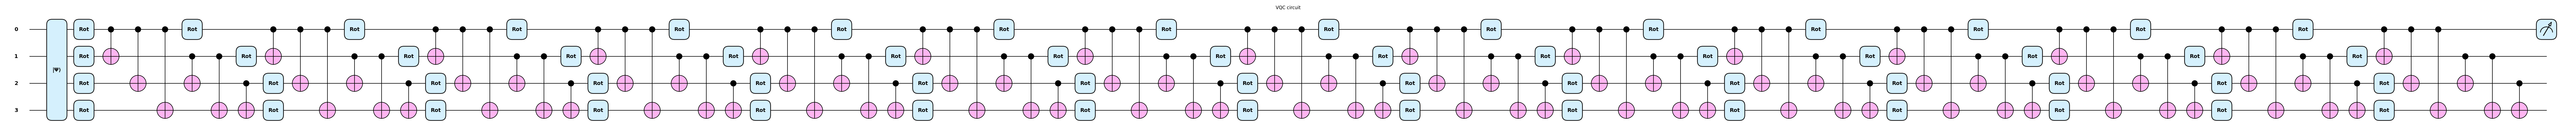

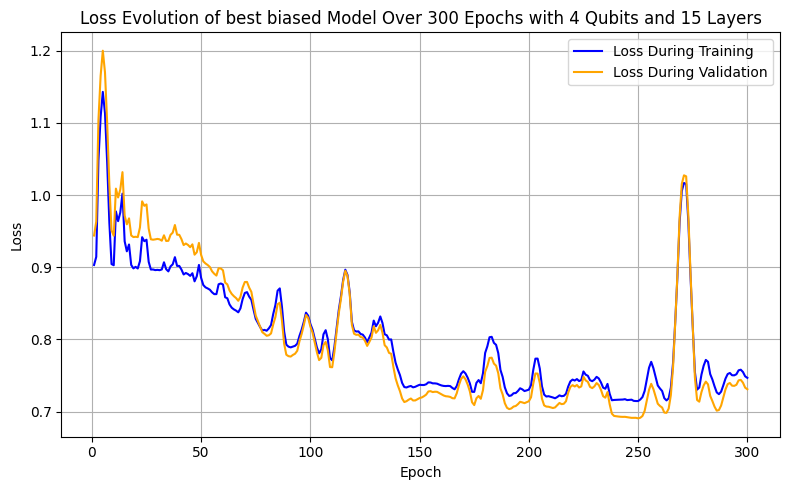

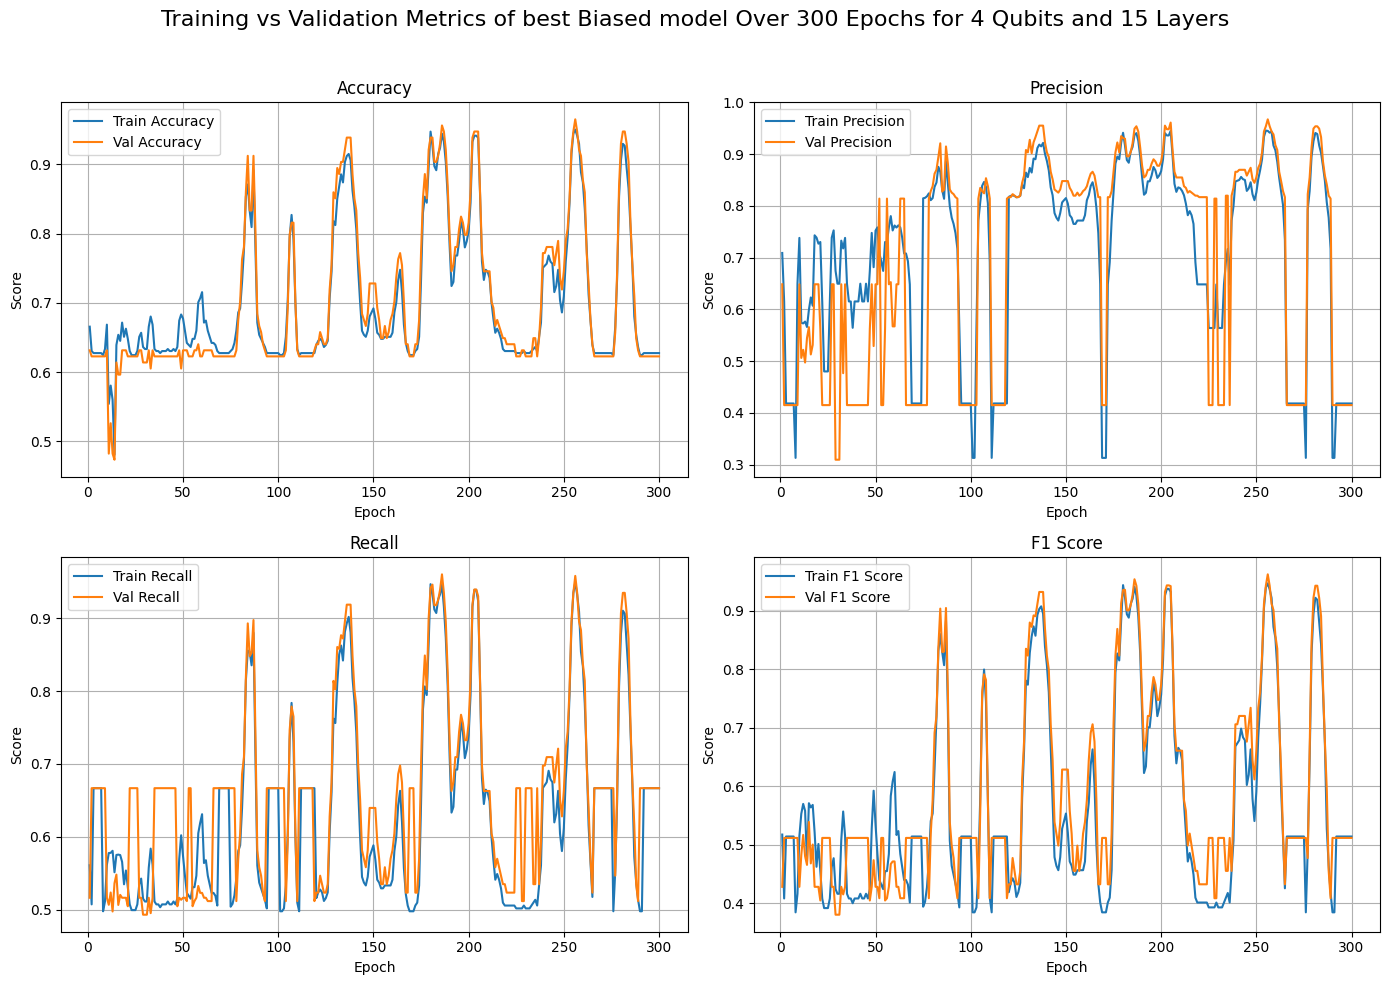

In [ ]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))


best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0

best_losses=[]
best_val_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

biased_test_acc=[]
biased_test_prec=[]
biased_test_rec=[]
biased_test_f1=[]

best_epoch=0
biased=True

for num_layers in layers:


    layer_acc=[] # For Test set
    layer_prec=[] # For Test set
    layer_rec=[] # For Test set
    layer_f1=[] # For Test set
    layer_epoch=[] # For Test set
    layer_time=[]  # For Training time

    for rep in range(runs):
        print(f"---> Repetition {rep+1}/{runs} for VQC with {num_qubits} Qubits and {num_layers} Layers <---\n")

        weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
        bias_init = np.array(0.0,requires_grad=biased)


        opt = NesterovMomentumOptimizer(0.01)
        batch_size = 5

        # Tracking loss
        losses = []
        val_losses=[]

        # Tracking Train accuracy
        tr_acc=[]

        # Tracking Validation accuracy
        val_acc=[]

        # Tracking Train precision
        tr_prec=[]

        # Tracking Validation precision
        val_prec=[]

        # Tracking Train recall
        tr_recall=[]

        # Tracking Validation recall
        val_recall=[]

        # Tracking Train F1
        tr_f1=[]

        # Tracking Validation F1
        val_f1=[]

        # Initialize weights
        weights = weights_init
        bias = bias_init
        
        val_best_acc=0.0
        val_best_weights=None
        val_best_bias=0.0

        val_best_epoch=0

        start=time.perf_counter()
        # We Train inside this loop
        for it in range(num_epochs):
            # Mini-batch sampling
            batch_index = np.random.randint(0, num_data, (batch_size,))
            feats_train_batch = features[batch_index]
            Y_train_batch = y_train[batch_index]

            # Optimizer step
            weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

            plot=False
            # Predictions
            pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
            pred_val = np.sign(variational_classifier(weights, bias, features_val))

            # Metrics
            acc_train = accuracy_score(y_train, pred_train)
            acc_val = accuracy_score(y_val, pred_val)
            prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
            prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
            rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
            rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
            f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
            f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

            tr_acc.append(acc_train)
            val_acc.append(acc_val)
            tr_prec.append(prec_train)
            val_prec.append(prec_val)
            tr_recall.append(rec_train)
            val_recall.append(rec_val)
            tr_f1.append(f1_train)
            val_f1.append(f1_val)

            # Track loss
            _cost = cost(weights, bias, features, y_train)
            val_cost = cost(weights, bias, features_val, y_val)

            losses.append(_cost)
            val_losses.append(val_cost)

            # we find the best accuracy achieved and the weights that correspond to it
            if acc_val>val_best_acc:
                val_best_weights=weights.copy()
                val_best_bias=bias.copy()
                val_best_acc=acc_val
                val_best_epoch=it
        end=time.perf_counter()
        # We Test here and keep the accuracy

        weights=val_best_weights.copy()
        bias=val_best_bias
        pred_test = np.sign(variational_classifier(weights, bias, features_test))
        

        acc_test = accuracy_score(y_test, pred_test)
        prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
        rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
        f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

        biased_test_acc.append(acc_test)
        biased_test_prec.append(prec_test)
        biased_test_rec.append(rec_test)
        biased_test_f1.append(f1_test)

        layer_acc.append(acc_test)
        layer_prec.append(prec_test)
        layer_rec.append(rec_test)
        layer_f1.append(f1_test)
        layer_epoch.append(val_best_epoch)
        layer_time.append(end-start)


        if acc_test>best_accuracy:
            best_accuracy=acc_test
            best_layer=num_layers
            best_weights=weights.copy()
            best_bias=bias.copy()

            best_losses=losses
            best_val_losses=val_losses
            best_epoch=val_best_epoch

            best_train_acc=tr_acc
            best_train_prec=tr_prec
            best_train_rec=tr_recall
            best_train_f1=tr_f1

            best_val_acc=val_acc
            best_val_prec=val_prec
            best_val_rec=val_recall
            best_val_f1=val_f1


    # Train and Test for all layers, keeping best weights and bias
    # Keep track of Test Metrics for each layer throughout 10 runs

    metrics_dict_biased[num_layers]['Accuracy']=layer_acc
    metrics_dict_biased[num_layers]['Precision']=layer_prec
    metrics_dict_biased[num_layers]['Recall']=layer_rec
    metrics_dict_biased[num_layers]['F1']=layer_f1
    metrics_dict_biased[num_layers]['Best Epoch']=layer_epoch
    metrics_dict_biased[num_layers]['Training Time']=layer_time

    print(f"\n Average Test set performance of Biased VQC for {num_qubits} Qubits and {num_layers} Layers:")
    print(f"Accuracy : {np.mean(np.array(metrics_dict_biased[num_layers]['Accuracy'])):.4f}")
    print(f"Precision: {np.mean(np.array(metrics_dict_biased[num_layers]['Precision'])):.4f}")
    print(f"Recall   : {np.mean(np.array(metrics_dict_biased[num_layers]['Recall'])):.4f}")
    print(f"F1-score : {np.mean(np.array(metrics_dict_biased[num_layers]['F1'])):.4f}")

pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

np.savez("./model_params/10_runs/biased/4_qubits/biased_params_4_qubits.npz", weights=best_weights, bias=best_bias)


print(f"\n--> Test Set Evaluation of Biased VQC's best model achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.plot(range(1, num_epochs + 1), best_val_losses,label='Loss During Validation', linestyle='-', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution of best biased Model Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics of best Biased model Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [35]:
np.save("./results/unbiased/4_qubits/metrics_dict.npy", metrics_dict, allow_pickle=True)

In [36]:
metrics_dict = np.load("./results/unbiased/4_qubits/metrics_dict.npy", allow_pickle=True).item()

In [37]:
np.save("./results/biased/4_qubits/metrics_dict_biased.npy", metrics_dict_biased, allow_pickle=True)

In [38]:
metrics_dict_biased = np.load("./results/biased/4_qubits/metrics_dict_biased.npy", allow_pickle=True).item()

In [ ]:
for i in layers:
    print(f'\nMetrics for Unbiased VQC with {num_qubits} Qubits and {i} Layers:')
    print(f" -> Mean Accuracy score: {np.mean(np.array(metrics_dict[i]['Accuracy'])):.4f}")
    print(f" -> Mean Recall score: {np.mean(np.array(metrics_dict[i]['Recall'])):.4f}")
    print(f" -> Mean Precision score: {np.mean(np.array(metrics_dict[i]['Precision'])):.4f}")
    print(f" -> Mean F1 score: {np.mean(np.array(metrics_dict[i]['F1'])):.4f}")
    print(f" -> Mean Best Epoch: {np.mean(np.array(metrics_dict[i]['Best Epoch'])):.4f}")
    print(f" -> Mean Training Time: {np.mean(np.array(metrics_dict[i]['Training Time'])):.4f} seconds")



Metrics for Unbiased VQC with 4 Qubits and 1 Layers:
 -> Mean Accuracy score: 0.6140
 -> Mean Recall score: 0.5010
 -> Mean Precision score: 0.5035
 -> Mean F1 score: 0.4364
 -> Mean Best Epoch: 108.0000
 -> Mean Training Time: 16.0607 seconds

Metrics for Unbiased VQC with 4 Qubits and 5 Layers:
 -> Mean Accuracy score: 0.7202
 -> Mean Recall score: 0.6555
 -> Mean Precision score: 0.7299
 -> Mean F1 score: 0.6452
 -> Mean Best Epoch: 252.1000
 -> Mean Training Time: 56.1875 seconds

Metrics for Unbiased VQC with 4 Qubits and 10 Layers:
 -> Mean Accuracy score: 0.8956
 -> Mean Recall score: 0.8732
 -> Mean Precision score: 0.9071
 -> Mean F1 score: 0.8835
 -> Mean Best Epoch: 241.5000
 -> Mean Training Time: 98.0221 seconds

Metrics for Unbiased VQC with 4 Qubits and 15 Layers:
 -> Mean Accuracy score: 0.9342
 -> Mean Recall score: 0.9172
 -> Mean Precision score: 0.9447
 -> Mean F1 score: 0.9270
 -> Mean Best Epoch: 226.6000
 -> Mean Training Time: 146.1546 seconds


In [40]:
for i in layers:
    print(f'\nMetrics for Biased VQC with {num_qubits} Qubits and {i} Layers:')
    print(f" -> Mean Accuracy score: {np.mean(np.array(metrics_dict_biased[i]['Accuracy'])):.4f}")
    print(f" -> Mean Recall score: {np.mean(np.array(metrics_dict_biased[i]['Recall'])):.4f}")
    print(f" -> Mean Precision score: {np.mean(np.array(metrics_dict_biased[i]['Precision'])):.4f}")
    print(f" -> Mean F1 score: {np.mean(np.array(metrics_dict_biased[i]['F1'])):.4f}")
    print(f" -> Mean Best Epoch: {np.mean(np.array(metrics_dict_biased[i]['Best Epoch'])):.4f}")
    print(f" -> Mean Training Time: {np.mean(np.array(metrics_dict_biased[i]['Training Time'])):.4f} seconds")


Metrics for Biased VQC with 4 Qubits and 1 Layers:
 -> Mean Accuracy score: 0.6123
 -> Mean Recall score: 0.4996
 -> Mean Precision score: 0.4990
 -> Mean F1 score: 0.4355
 -> Mean Best Epoch: 29.1000
 -> Mean Training Time: 15.7031 seconds

Metrics for Biased VQC with 4 Qubits and 5 Layers:
 -> Mean Accuracy score: 0.8246
 -> Mean Recall score: 0.8065
 -> Mean Precision score: 0.8203
 -> Mean F1 score: 0.8069
 -> Mean Best Epoch: 252.4000
 -> Mean Training Time: 56.5878 seconds

Metrics for Biased VQC with 4 Qubits and 10 Layers:
 -> Mean Accuracy score: 0.8991
 -> Mean Recall score: 0.8844
 -> Mean Precision score: 0.9065
 -> Mean F1 score: 0.8901
 -> Mean Best Epoch: 243.4000
 -> Mean Training Time: 98.9235 seconds

Metrics for Biased VQC with 4 Qubits and 15 Layers:
 -> Mean Accuracy score: 0.9272
 -> Mean Recall score: 0.9181
 -> Mean Precision score: 0.9288
 -> Mean F1 score: 0.9210
 -> Mean Best Epoch: 206.8000
 -> Mean Training Time: 151.0557 seconds


In [41]:
def print_metrics(metrics_dict, name):
    print(f"\n{name} Set:")
    print(f"  Accuracy : {metrics_dict['accuracy']:.4f}")
    print(f"  Precision: {metrics_dict['precision']:.4f}")
    print(f"  Recall   : {metrics_dict['recall']:.4f}")
    print(f"  F1-Score : {metrics_dict['f1']:.4f}")

def get_metrics(x,y,clf):
    metrics_dict={}
    metrics_dict['accuracy'] = np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=5))
    metrics_dict['precision'] =np.mean(cross_val_score(clf,x,y,scoring='precision',cv=5))
    metrics_dict['recall'] =np.mean(cross_val_score(clf,x,y,scoring='recall',cv=5))
    metrics_dict['f1'] =np.mean(cross_val_score(clf,x,y,scoring='f1',cv=5))

    return metrics_dict

In [42]:
# Classical ML method: SVM

svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=svm_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=svm_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=svm_clf)

print("-----> SVM Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> SVM Results <-----

Train Set:
  Accuracy : 0.9326
  Precision: 0.9818
  Recall   : 0.8351
  F1-Score : 0.9019

Validation Set:
  Accuracy : 0.8866
  Precision: 0.9667
  Recall   : 0.7250
  F1-Score : 0.8264

Test Set:
  Accuracy : 0.9735
  Precision: 1.0000
  Recall   : 0.9278
  F1-Score : 0.9616


In [43]:
# Classical ML method: Logistic Regression
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=lr_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=lr_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=lr_clf)

print("-----> Logistic Regression Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Logistic Regression Results <-----

Train Set:
  Accuracy : 0.8974
  Precision: 0.9882
  Recall   : 0.7323
  F1-Score : 0.8404

Validation Set:
  Accuracy : 0.8170
  Precision: 0.9500
  Recall   : 0.5417
  F1-Score : 0.6782

Test Set:
  Accuracy : 0.9822
  Precision: 1.0000
  Recall   : 0.9528
  F1-Score : 0.9749


In [44]:
# Classical ML method: Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=rf_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=rf_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=rf_clf)

print("-----> Random Forest Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Random Forest Results <-----

Train Set:
  Accuracy : 0.9268
  Precision: 0.9076
  Recall   : 0.8982
  F1-Score : 0.9022

Validation Set:
  Accuracy : 0.9387
  Precision: 0.9133
  Recall   : 0.9333
  F1-Score : 0.9187

Test Set:
  Accuracy : 0.9296
  Precision: 0.9417
  Recall   : 0.8556
  F1-Score : 0.8943
